In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import seaborn as sns
from scipy.stats import norm


def fetch_chain_options(ticker="SPY", expiry=None):
    stock = yf.Ticker(ticker)
    options = stock.option_chain(expiry)
    return options.calls, options.puts

calls, puts = fetch_chain_options()
calls.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260311C00585000,2026-03-10 15:01:13+00:00,585.0,96.60,89.64,92.43,0.000000,0.000000,1.0,0,1.667482,True,REGULAR,USD
1,SPY260311C00595000,2026-03-11 15:22:03+00:00,595.0,80.39,79.64,82.43,2.400002,3.077320,16.0,13,1.507815,True,REGULAR,USD
2,SPY260311C00605000,2026-03-11 19:52:08+00:00,605.0,70.94,69.64,72.43,-4.799995,-6.337464,3.0,6,1.348148,True,REGULAR,USD
3,SPY260311C00615000,2026-03-11 14:09:55+00:00,615.0,63.04,59.65,62.43,1.430000,2.321052,3.0,35,1.187992,True,REGULAR,USD
4,SPY260311C00625000,2026-03-11 16:45:01+00:00,625.0,50.31,49.64,52.43,-2.369999,-4.498859,2.0,18,1.026860,True,REGULAR,USD


Surface de vol
-------------------

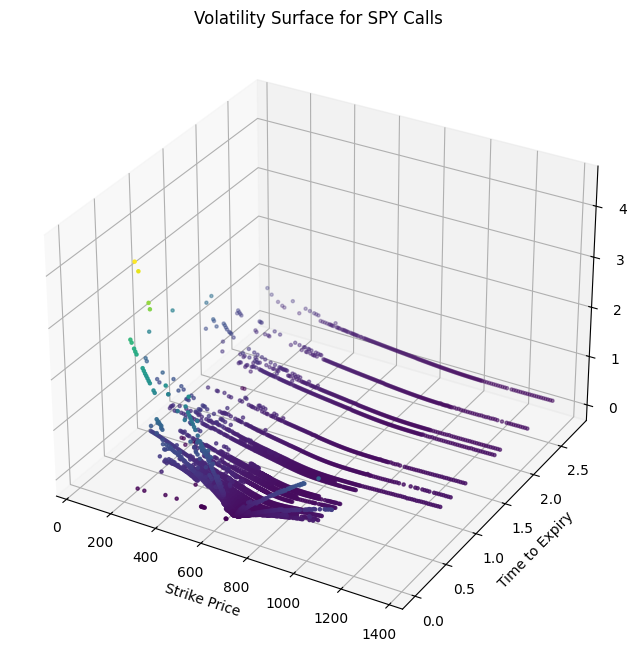

In [6]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

tk = yf.Ticker("SPY")

all_calls = []
for exp in tk.options:
    chain = tk.option_chain(exp)
    calls = chain.calls.copy()
    calls["expiration"] = exp
    all_calls.append(calls)

df = pd.concat(all_calls, ignore_index=True)

df["expiration"] = pd.to_datetime(df["expiration"])
today = pd.Timestamp("today").normalize()
df["tte"] = (df["expiration"] - today).dt.days / 365

df = df[df["tte"] > 0]
df = df[df["impliedVolatility"] > 0]
df = df.dropna(subset=["strike", "impliedVolatility", "tte"])

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(df["strike"], df["tte"], df["impliedVolatility"],
           c=df["impliedVolatility"], cmap="viridis", s=5)

ax.set_xlabel("Strike Price")
ax.set_ylabel("Time to Expiry")
ax.set_zlabel("Implied Volatility")
ax.set_title("Volatility Surface for SPY Calls")

plt.show()

In [7]:
def blacandscholes(S,K,r,vol,T):
    d1 = (np.log(S/K) + (r+(vol**2/2))*T) / (vol*np.sqrt(T))
    d2 = d1 - vol*np.sqrt(T)
    call_price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    put_price = K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return call_price, put_price

s = yf.Ticker("SPY").history(period="1d")["Close"].iloc[0]
K = 680
r = 0.03
vol = 0.2
T = 30/365
call_price, put_price = blacandscholes(s, K, r, vol, T)
print(f"Call Price: {call_price:.2f}, Put Price: {put_price:.2f}")

Call Price: 14.51, Put Price: 16.51


/var/folders/dp/9gbs5ccj4p38dhz5lvdhvbnh0000gn/T/ipykernel_2987/2728324683.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


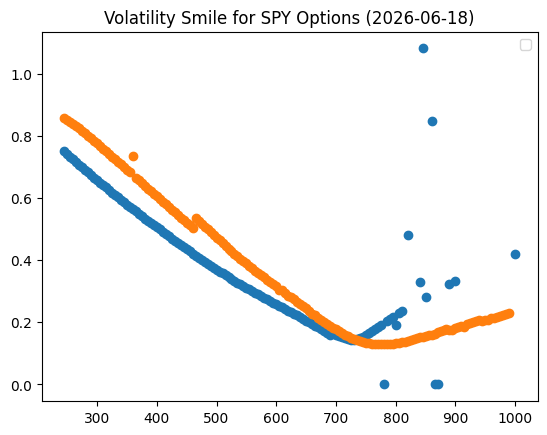

In [8]:
#callspread for a chain option
data = yf.Ticker("SPY").option_chain("2026-06-18").puts
data2 = yf.Ticker("SPY").option_chain("2026-06-18").calls
data.head()

plt.plot(data["strike"], data["impliedVolatility"], marker="o", linestyle="")
plt.plot(data2["strike"], data2["impliedVolatility"], marker="o", linestyle="")
plt.legend()
plt.title("Volatility Smile for SPY Options (2026-06-18)")
plt.show()

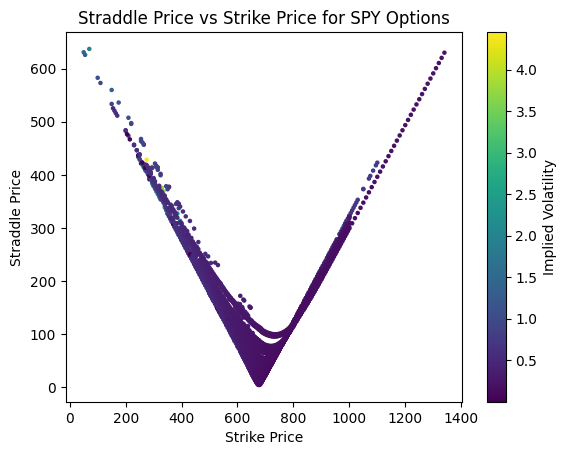

In [9]:
def straddle_price(S, K, r, vol, T):
    call_price, put_price = blacandscholes(S, K, r, vol, T)
    return call_price + put_price

df = df[df["tte"] <= 252 / 252] 

S = yf.Ticker("SPY").history(period="1d")["Close"].iloc[0]

for index, row in df.iterrows():
    K = row["strike"]
    r = 0.03
    vol = row["impliedVolatility"]
    T = row["tte"]
    df.at[index, "straddle_price"] = straddle_price(S, K, r, vol, T)

plt.scatter(df["strike"], df["straddle_price"], c=df["impliedVolatility"], cmap="viridis", s=5)
plt.xlabel("Strike Price")
plt.ylabel("Straddle Price")
plt.title("Straddle Price vs Strike Price for SPY Options")
plt.colorbar(label="Implied Volatility")
plt.show()

In [10]:
call_595 = df[(df["strike"] == 595) & (df["tte"] <= 252 / 252)]
call_620 = df[(df["strike"] == 620) & (df["tte"] <= 252 / 252)]
spot = yf.Ticker("SPY").history(period="1d")["Close"].iloc[0]
call_spread_price = (call_595["straddle_price"].values[0] - call_620["straddle_price"].values[0])/spot
print(f"Call Spread en % du spot: {call_spread_price:.4f}")

Call Spread en % du spot: 0.0379
